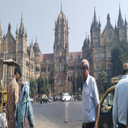

✅ Completed in 102.69 seconds
🎨 Stylized image saved: stylized_output.jpg


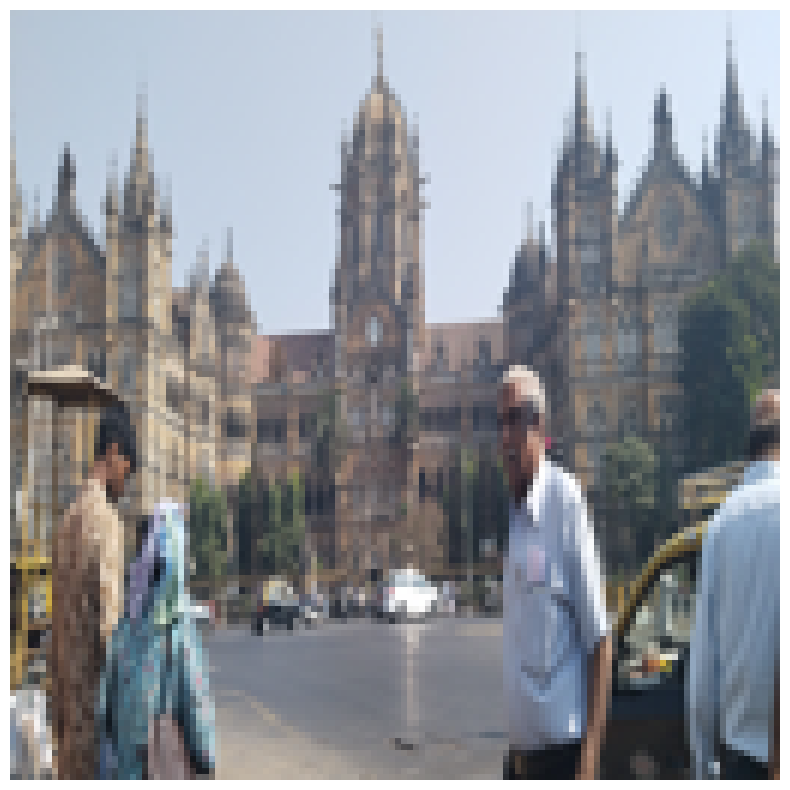

In [11]:
import os
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import IPython.display
import tensorflow as tf

# ---------------------------
# Configs
# ---------------------------
MODEL_PATH = "C:/7th Sem Project/TarunProject/custom_vgg19_feature_extractor_fixed.keras"
content_path = "C:/7th Sem Project/TarunProject/Neural-Style_Transfer/neural-style-transfer/content_image/main_content.jpg"
style_path   = "C:/7th Sem Project/TarunProject/Neural-Style_Transfer/neural-style-transfer/style_image/vincent.jpg"
OUTPUT_PATH  = "stylized_output.jpg"
INTERMEDIATE_DIR = "style_progress"

IMG_SIZE = (128, 128)

# ---------------------------
# Load Model
# ---------------------------
print("🔄 Loading feature extractor:", MODEL_PATH)
model_custom = tf.keras.models.load_model(MODEL_PATH, compile=False)
model_custom.trainable = False
print("✅ Model loaded successfully with", len(model_custom.layers), "layers total.")

# ---------------------------
# Select all Conv2D layers
# ---------------------------
conv_layers = [l.name for l in model_custom.layers if isinstance(l, tf.keras.layers.Conv2D)]
print(f"🎨 Total convolutional layers detected: {len(conv_layers)}")
print("📋 Conv layers:", conv_layers)

if len(conv_layers) < 3:
    raise ValueError("❌ Not enough convolutional layers found for NST!")

# Use all conv layers for style, last 2 for content
style_layers = conv_layers[:-2]
content_layers = conv_layers[-2:]

print(f"🎨 Using {len(style_layers)} style layers")
print(f"🎯 Using {len(content_layers)} content layers")

# ---------------------------
# Build extractor for selected layers
# ---------------------------
outputs = [model_custom.get_layer(name).output for name in (style_layers + content_layers)]
extractor = tf.keras.Model(inputs=model_custom.input, outputs=outputs)
extractor.trainable = False

# ---------------------------
# Helper Functions
# ---------------------------
def load_img_fixed_size(path, target_size=IMG_SIZE):
    img = Image.open(path).convert('RGB')
    img = img.resize(target_size, Image.BICUBIC)
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return tf.convert_to_tensor(arr)

def deprocess_img(img_tensor):
    x = img_tensor.numpy()
    if x.shape[0] == 1:
        x = x[0]
    x = np.clip(x * 255.0, 0, 255).astype('uint8')
    return x

def gram_matrix(x):
    x = tf.reshape(x, [-1, x.shape[-1]])
    gram = tf.matmul(x, x, transpose_a=True)
    return gram / tf.cast(tf.shape(x)[0], tf.float32)

def style_loss(base, target_gram):
    gm = gram_matrix(base)
    return tf.reduce_mean(tf.square(gm - target_gram))

def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))

# ---------------------------
# Extract Features
# ---------------------------
style_image = load_img_fixed_size(style_path)
content_image = load_img_fixed_size(content_path)

outputs_style = extractor(style_image)
outputs_content = extractor(content_image)

num_style_layers = len(style_layers)
num_content_layers = len(content_layers)

style_features = outputs_style[:num_style_layers]
content_features = outputs_content[num_style_layers:]

gram_style_features = [gram_matrix(f) for f in style_features]

# ---------------------------
# Optimization
# ---------------------------
init_image = tf.Variable(content_image, dtype=tf.float32)
optimizer = tf.keras.optimizers.Adam(learning_rate=5.0, epsilon=1e-1)

style_weight = 5e-3
content_weight = 1.0

os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

def compute_loss_and_grads(init_image):
    with tf.GradientTape() as tape:
        outputs = extractor(init_image)
        out_style = outputs[:num_style_layers]
        out_content = outputs[num_style_layers:]

        s_loss = tf.add_n([style_loss(o[0], t) for o, t in zip(out_style, gram_style_features)])
        s_loss *= style_weight / max(1, num_style_layers)

        c_loss = tf.add_n([content_loss(o[0], t[0]) for o, t in zip(out_content, content_features)])
        c_loss *= content_weight / max(1, num_content_layers)

        total_loss = s_loss + c_loss

    grads = tape.gradient(total_loss, init_image)
    return grads, total_loss, s_loss, c_loss

# ---------------------------
# Run Style Transfer
# ---------------------------
num_iterations = 300
display_interval = 25
best_img = None
best_loss = float('inf')

start = time.time()
for i in range(1, num_iterations + 1):
    grads, loss, s_l, c_l = compute_loss_and_grads(init_image)
    optimizer.apply_gradients([(grads, init_image)])
    init_image.assign(tf.clip_by_value(init_image, 0.0, 1.0))

    if loss < best_loss:
        best_loss = loss
        best_img = deprocess_img(init_image)

    if i % display_interval == 0 or i == num_iterations:
        print(f"Iter {i}/{num_iterations} — total: {loss:.4e} | style: {s_l:.4e} | content: {c_l:.4e}")
        IPython.display.clear_output(wait=True)
        display_img = deprocess_img(init_image)
        IPython.display.display(Image.fromarray(display_img))
        Image.fromarray(display_img).save(os.path.join(INTERMEDIATE_DIR, f"iter_{i:03d}.jpg"))

print("✅ Completed in", round(time.time() - start, 2), "seconds")

# ---------------------------
# Save Final Stylized Image
# ---------------------------
if best_img is not None:
    result_img = Image.fromarray(best_img)
    result_img.save(OUTPUT_PATH)
    print("🎨 Stylized image saved:", OUTPUT_PATH)
    plt.imshow(best_img)
    plt.axis('off')
    plt.show()
else:
    print("❌ No stylized image generated.")
